# Strava Analyzer Starter Notebook
Run ingest/catalog/context pipeline, then analyze structured commute patterns.

In [2]:
from pathlib import Path

from strava_analyzer.ingest import ingest_export
from strava_analyzer.query import (
    commute_counts_by_year,
    commute_route_selection,
    commute_speed_by_period,
    connect,
    equipment_distance_by_month,
    equipment_distance_by_year,
    equipment_distance_totals,
    filter_activities,
)

In [3]:
ingest_export(account_export_dir=Path("../account_export").resolve())

,activity_id,activity_datetime,activity_name,activity_type,distance_m,elapsed_time_s,moving_time_s,average_speed_mps,elevation_gain_m,equipment_name,...,route_point_count,route_start_lat,route_start_lon,route_end_lat,route_end_lon,route_bbox_min_lat,route_bbox_max_lat,route_bbox_min_lon,route_bbox_max_lon,route_polyline_hint
0,960245903,2017-04-25 15:20:00,Daily Commute,Ride,8046.7,4800,4800.0,NaN,15.2,NaN,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
1,970619226,2017-05-04 13:52:01,Morning Commute,Ride,5665.6,1003,945.0,NaN,14.9,NaN,...,868,43.087719,-89.369353,43.074103,-89.404880,43.064364,43.088004,-89.404880,-89.367060,"43.08772,-89.36935 | 43.06905,-89.38373 | 43.0..."
2,971322621,2017-05-04 23:09:31,Evening Run,Run,0.0,0,0.0,NaN,0.0,NaN,...,1,43.073444,-89.404698,43.073444,-89.404698,43.073444,43.073444,-89.404698,-89.404698,"43.07344,-89.40470"
3,971341632,2017-05-04 23:09:47,Evening Ride,Ride,5774.4,1231,1098.0,NaN,0.0,NaN,...,890,43.073345,-89.404443,43.087805,-89.369063,43.064266,43.087979,-89.404443,-89.368726,"43.07335,-89.40444 | 43.07066,-89.38104 | 43.0..."
4,976833978,2017-05-05 13:58:28,Morning Ride,Ride,6952.5,29755,1548.0,NaN,30.9,NaN,...,1041,43.087557,-89.368853,43.087777,-89.369162,43.072794,43.088177,-89.405309,-89.368853,"43.08756,-89.36885 | 43.07289,-89.39791 | 43.0..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
857,17766728970,2026-03-18 12:50:30,Morning Ride,Ride,13283.8,3205,2271.0,5.849,74.9,FX,...,2228,43.085267,-89.362529,43.021987,-89.466110,43.021545,43.085543,-89.466518,-89.362499,"43.08527,-89.36253 | 43.06586,-89.42091 | 43.0..."
858,17772326680,2026-03-18 21:12:37,Afternoon Ride,Ride,13501.1,2326,1869.0,7.224,29.6,FX,...,1835,43.021746,-89.466086,43.085390,-89.362540,43.021494,43.085570,-89.466462,-89.361730,"43.02175,-89.46609 | 43.06696,-89.41639 | 43.0..."
859,17791020276,2026-03-20 12:02:50,Morning Ride,Ride,13660.9,5201,2394.0,5.706,73.6,FX,...,2351,43.085442,-89.362518,43.021792,-89.466439,43.021685,43.085555,-89.466516,-89.362518,"43.08544,-89.36252 | 43.06360,-89.42534 | 43.0..."
860,17795946649,2026-03-20 20:49:27,Afternoon Ride,Ride,11086.1,3882,1775.0,6.246,24.0,FX,...,1759,43.024386,-89.459805,43.050167,-89.395215,43.023293,43.050609,-89.459805,-89.387006,"43.02439,-89.45981 | 43.03542,-89.41362 | 43.0..."


In [4]:
con = connect()
commute_counts_by_year(con)

,year,commute_count
0,2024,226
1,2025,244
2,2026,1


In [5]:
commute_speed_by_period(con, year=2024)

,commute_period,avg_speed_mps,commute_count,avg_speed_kmh
0,am,6.754975,114,24.317911
1,pm,7.552038,112,27.187337


In [6]:
route_mix = commute_route_selection(con)
route_mix

,route_label,commute_count
0,sw,201
1,arb,142
2,cannon,52
3,capcity,19
4,arb_plus,14
5,midvale,5
6,cannon_seminole,3
7,sw_tennis,2
8,swarbcanon,2
9,volunteer,2


<Axes: xlabel='route_label'>

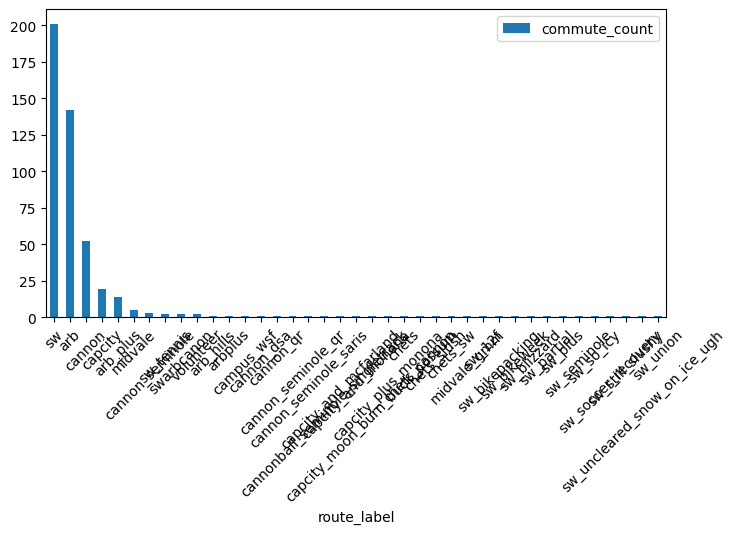

In [7]:
route_mix.plot.bar(x='route_label', y='commute_count', rot=45, figsize=(8,4))

In [8]:
filter_activities(con)

,activity_id,activity_datetime,activity_name,activity_type,distance_m,elapsed_time_s,moving_time_s,average_speed_mps,elevation_gain_m,equipment_name,...,route_point_count,route_start_lat,route_start_lon,route_end_lat,route_end_lon,route_bbox_min_lat,route_bbox_max_lat,route_bbox_min_lon,route_bbox_max_lon,route_polyline_hint
0,17808990478,2026-03-21 21:00:53,Afternoon Ride,Ride,47564.0,7328,6747.0,7.050,311.4,FX,...,6630,43.085395,-89.362626,43.085330,-89.362569,43.009123,43.094119,-89.461055,-89.315824,"43.08539,-89.36263 | 43.01775,-89.40348 | 43.0..."
1,17795946649,2026-03-20 20:49:27,Afternoon Ride,Ride,11086.1,3882,1775.0,6.246,24.0,FX,...,1759,43.024386,-89.459805,43.050167,-89.395215,43.023293,43.050609,-89.459805,-89.387006,"43.02439,-89.45981 | 43.03542,-89.41362 | 43.0..."
2,17791020276,2026-03-20 12:02:50,Morning Ride,Ride,13660.9,5201,2394.0,5.706,73.6,FX,...,2351,43.085442,-89.362518,43.021792,-89.466439,43.021685,43.085555,-89.466516,-89.362518,"43.08544,-89.36252 | 43.06360,-89.42534 | 43.0..."
3,17772326680,2026-03-18 21:12:37,Afternoon Ride,Ride,13501.1,2326,1869.0,7.224,29.6,FX,...,1835,43.021746,-89.466086,43.085390,-89.362540,43.021494,43.085570,-89.466462,-89.361730,"43.02175,-89.46609 | 43.06696,-89.41639 | 43.0..."
4,17766728970,2026-03-18 12:50:30,Morning Ride,Ride,13283.8,3205,2271.0,5.849,74.9,FX,...,2228,43.085267,-89.362529,43.021987,-89.466110,43.021545,43.085543,-89.466518,-89.362499,"43.08527,-89.36253 | 43.06586,-89.42091 | 43.0..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
857,976833978,2017-05-05 13:58:28,Morning Ride,Ride,6952.5,29755,1548.0,NaN,30.9,None,...,1041,43.087557,-89.368853,43.087777,-89.369162,43.072794,43.088177,-89.405309,-89.368853,"43.08756,-89.36885 | 43.07289,-89.39791 | 43.0..."
858,971341632,2017-05-04 23:09:47,Evening Ride,Ride,5774.4,1231,1098.0,NaN,0.0,None,...,890,43.073345,-89.404443,43.087805,-89.369063,43.064266,43.087979,-89.404443,-89.368726,"43.07335,-89.40444 | 43.07066,-89.38104 | 43.0..."
859,971322621,2017-05-04 23:09:31,Evening Run,Run,0.0,0,0.0,NaN,0.0,None,...,1,43.073444,-89.404698,43.073444,-89.404698,43.073444,43.073444,-89.404698,-89.404698,"43.07344,-89.40470"
860,970619226,2017-05-04 13:52:01,Morning Commute,Ride,5665.6,1003,945.0,NaN,14.9,None,...,868,43.087719,-89.369353,43.074103,-89.404880,43.064364,43.088004,-89.404880,-89.367060,"43.08772,-89.36935 | 43.06905,-89.38373 | 43.0..."


In [9]:
activities_2024 = con.execute(
    """
    SELECT *
    FROM activities
    WHERE EXTRACT(year FROM activity_datetime) = 2024
    ORDER BY activity_datetime
    """
).fetch_df()
activities_2024 

,activity_id,activity_datetime,activity_name,activity_type,distance_m,elapsed_time_s,moving_time_s,average_speed_mps,elevation_gain_m,equipment_name,...,route_point_count,route_start_lat,route_start_lon,route_end_lat,route_end_lon,route_bbox_min_lat,route_bbox_max_lat,route_bbox_min_lon,route_bbox_max_lon,route_polyline_hint
0,10518042018,2024-01-08 13:57:31,Commute 7 (AM / Week 2 / Cannonball),Ride,13466.4,2049,1914.0,7.036,61.3,FX,...,1910,43.084204,-89.365135,43.021929,-89.466375,43.021661,43.084204,-89.466378,-89.363640,"43.08420,-89.36513 | 43.04680,-89.40272 | 43.0..."
1,10521043682,2024-01-08 22:40:08,Commute 8 (PM / Week 2 / SW),Ride,13417.2,2091,1894.0,7.084,29.7,FX,...,1888,43.021977,-89.466030,43.085364,-89.362543,43.021531,43.085591,-89.466655,-89.361766,"43.02198,-89.46603 | 43.06743,-89.41457 | 43.0..."
2,10524569487,2024-01-09 13:43:49,Commute 9 (Week 2 / AM / Arb),Ride,13525.5,2890,2006.0,6.743,103.9,FX,...,1998,43.084115,-89.364457,43.021926,-89.466437,43.021610,43.084260,-89.466477,-89.363595,"43.08411,-89.36446 | 43.04917,-89.41820 | 43.0..."
3,10527561025,2024-01-09 22:00:05,Commute 10 (Week 2 / PM / SW / Blizzard!),Ride,13396.4,2868,2403.0,5.575,35.9,FX,...,2397,43.022003,-89.466203,43.085453,-89.362644,43.021566,43.085583,-89.466641,-89.361800,"43.02200,-89.46620 | 43.06469,-89.42402 | 43.0..."
4,10537530134,2024-01-11 13:37:01,Commute 11 (Week 2 / AM / SW / Uncleared snow ...,Ride,13127.0,2613,2492.0,5.268,72.8,FX,...,2475,43.084166,-89.364626,43.022003,-89.466462,43.021596,43.084193,-89.466512,-89.363570,"43.08417,-89.36463 | 43.05812,-89.43318 | 43.0..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288,13234368330,2024-12-28 21:48:29,Skiing but without skis so trail running,Run,4971.8,2102,1954.0,2.544,135.1,None,...,2094,46.019928,-88.890850,46.019697,-88.891269,46.014824,46.023845,-88.903002,-88.890223,"46.01993,-88.89085 | 46.02079,-88.90153 | 46.0..."
289,13234368318,2024-12-29 17:28:37,Elvoy Springs Hike,Hike,2338.9,2176,1840.0,1.271,36.7,None,...,2167,46.007454,-88.902717,46.006929,-88.904003,46.006917,46.014712,-88.906943,-88.901330,"46.00745,-88.90272 | 46.01467,-88.90694 | 46.0..."
290,13234368386,2024-12-29 21:25:30,Rivers Reach Trail Run,Run,4903.0,3079,1956.0,2.507,98.9,None,...,3078,46.020003,-88.891100,46.019965,-88.890900,46.019949,46.031887,-88.892021,-88.881511,"46.02000,-88.89110 | 46.02432,-88.88555 | 46.0..."
291,13234368401,2024-12-30 18:25:19,Anvil Military Trailhead Lake Loop,Hike,5558.1,4580,4262.0,1.304,84.8,None,...,4581,45.919345,-89.065806,45.919438,-89.068755,45.906802,45.919869,-89.068838,-89.058030,"45.91934,-89.06581 | 45.90910,-89.06064 | 45.9..."


## Equipment Distance Tables
Examples: FX, Hardtail, etc.

In [15]:
equipment_distance_totals(con, equipment_terms=['FX','Hardtail', 'Jamis'])

,equipment_name,total_distance_m,total_distance_km,activity_count
0,Jamis,5563846.1,5563.8461,347
1,FX,2535932.6,2535.9326,186
2,Hardtail,918926.4,918.9264,49


In [11]:
equipment_distance_by_year(con, equipment_terms=['FX','Hardtail', 'Jamis'])

,year,equipment_name,total_distance_m,total_distance_km,activity_count
0,2024,FX,1133410.6,1133.4106,87
1,2024,Hardtail,324872.6,324.8726,21
2,2024,Jamis,2087189.8,2087.1898,151
3,2025,FX,734630.1,734.6301,54
4,2025,Hardtail,557194.2,557.1942,27
5,2025,Jamis,3460984.8,3460.9848,195
6,2026,FX,667891.9,667.8919,45
7,2026,Hardtail,36859.6,36.8596,1
8,2026,Jamis,15671.5,15.6715,1


In [12]:
equipment_distance_by_month(con, equipment_terms=['FX','Hardtail', 'Jamis'], year=2024)

,year,month,equipment_name,total_distance_m,total_distance_km,activity_count
0,2024,1,FX,210650.5,210.6505,16
1,2024,2,FX,278446.3,278.4463,22
2,2024,2,Hardtail,28777.1,28.7771,2
3,2024,3,FX,173033.2,173.0332,13
4,2024,3,Jamis,132446.5,132.4465,10
5,2024,4,FX,108500.2,108.5002,8
6,2024,4,Hardtail,27788.7,27.7887,2
7,2024,4,Jamis,148511.9,148.5119,11
8,2024,5,FX,26427.3,26.4273,2
9,2024,5,Hardtail,56315.9,56.3159,3


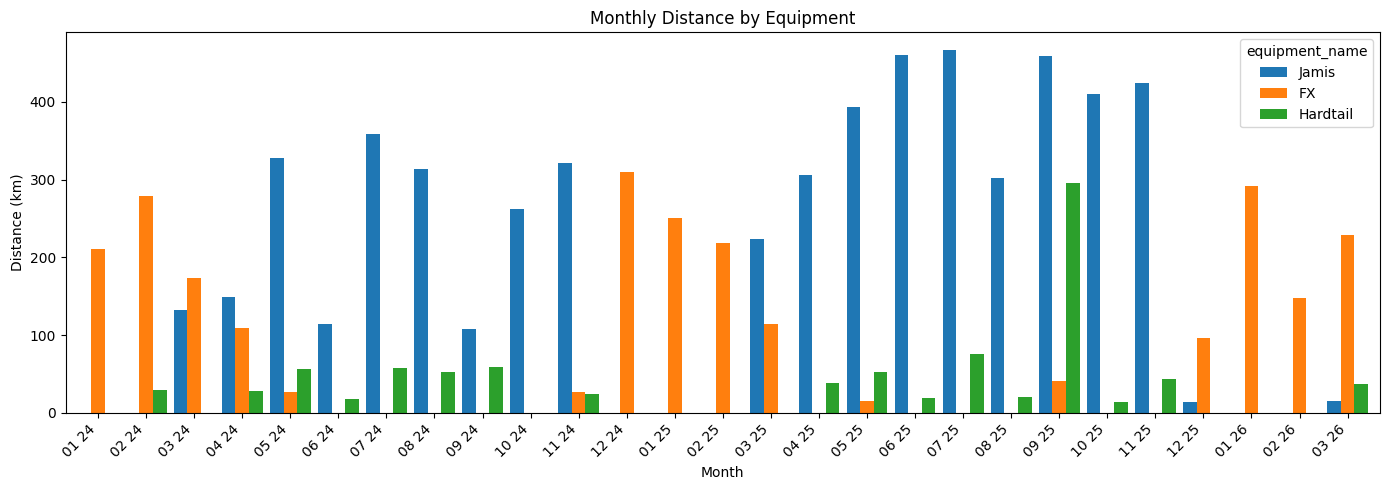

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

from strava_analyzer.query import equipment_distance_by_month

# Pull monthly totals for the three bikes
df = equipment_distance_by_month(
    con,
    equipment_terms=["Jamis", "FX", "Hardtail"],
    match_mode="exact",
)

# Build a month timeline and pivot to one column per bike
df["month_start"] = pd.to_datetime(
    dict(year=df["year"].astype(int), month=df["month"].astype(int), day=1)
)
pivot = (
    df.pivot_table(
        index="month_start",
        columns="equipment_name",
        values="total_distance_km",
        aggfunc="sum",
    )
    .fillna(0)
    .sort_index()
)

# Keep consistent order
pivot = pivot.reindex(columns=["Jamis", "FX", "Hardtail"], fill_value=0)
pivot.index = pivot.index.strftime("%m %y")


ax = pivot.plot(kind="bar", figsize=(14, 5), width=0.85)
ax.set_title("Monthly Distance by Equipment")
ax.set_xlabel("Month")
ax.set_ylabel("Distance (km)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


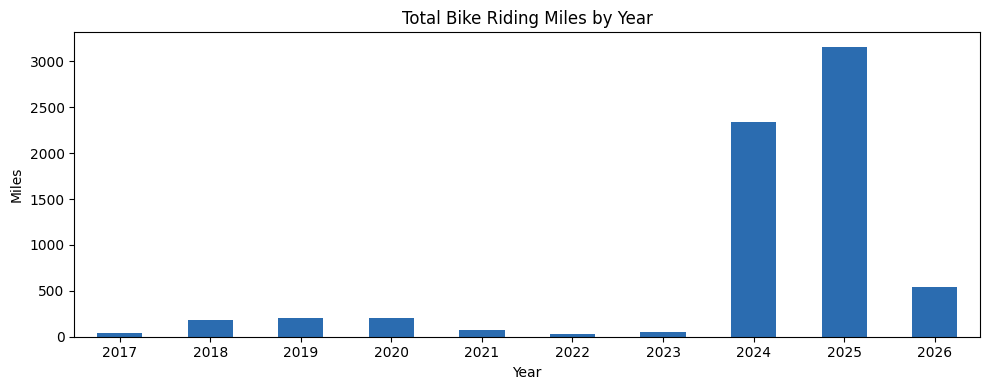

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

yearly_bike_miles = con.execute(
    """
    SELECT
      EXTRACT(year FROM activity_datetime)::INT AS year,
      SUM(distance_m) / 1609.344 AS total_miles
    FROM activities
    WHERE activity_datetime IS NOT NULL
      AND distance_m IS NOT NULL
      AND (
        LOWER(activity_type) LIKE '%ride%'
        OR LOWER(activity_type) LIKE '%bike%'
      )
    GROUP BY 1
    ORDER BY 1
    """
).fetch_df()

ax = yearly_bike_miles.plot(
    x="year",
    y="total_miles",
    kind="bar",
    legend=False,
    figsize=(10, 4),
    color="#2b6cb0",
)

ax.set_title("Total Bike Riding Miles by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Miles")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


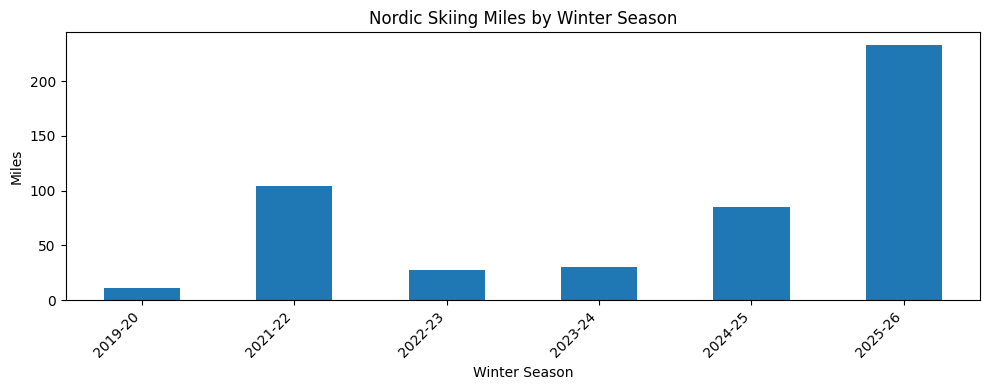

In [17]:
import matplotlib.pyplot as plt

# Choose when a new ski season starts (10 = Oct, 9 = Sep, etc.)
SEASON_START_MONTH = 10

ski_winter_miles = con.execute(
    f"""
    WITH ski AS (
      SELECT
        activity_datetime,
        distance_m,
        CASE
          WHEN EXTRACT(month FROM activity_datetime) >= {SEASON_START_MONTH}
            THEN EXTRACT(year FROM activity_datetime)::INT
          ELSE EXTRACT(year FROM activity_datetime)::INT - 1
        END AS season_start_year
      FROM activities
      WHERE activity_datetime IS NOT NULL
        AND distance_m IS NOT NULL
        AND LOWER(activity_type) LIKE '%nordic ski%'
    )
    SELECT
      season_start_year,
      CAST(season_start_year AS VARCHAR) || '-' ||
      RIGHT(CAST(season_start_year + 1 AS VARCHAR), 2) AS winter_season,
      SUM(distance_m) / 1609.344 AS total_miles
    FROM ski
    GROUP BY season_start_year, winter_season
    ORDER BY season_start_year
    """
).fetch_df()

ax = ski_winter_miles.plot(
    x="winter_season",
    y="total_miles",
    kind="bar",
    legend=False,
    figsize=(10, 4),
    color="#1f77b4",
)

ax.set_title("Nordic Skiing Miles by Winter Season")
ax.set_xlabel("Winter Season")
ax.set_ylabel("Miles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


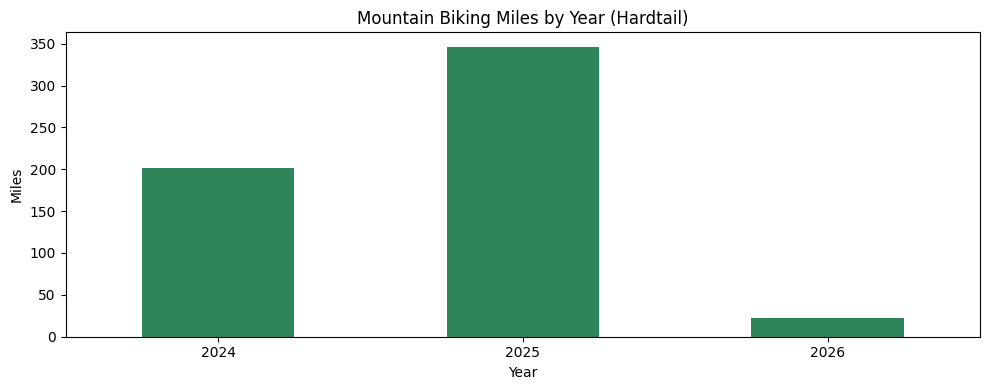

In [18]:
import matplotlib.pyplot as plt

mtb_miles_by_year = con.execute(
    """
    SELECT
      EXTRACT(year FROM activity_datetime)::INT AS year,
      SUM(distance_m) / 1609.344 AS total_miles
    FROM activities
    WHERE activity_datetime IS NOT NULL
      AND distance_m IS NOT NULL
      AND LOWER(equipment_name) = 'hardtail'
    GROUP BY 1
    ORDER BY 1
    """
).fetch_df()

ax = mtb_miles_by_year.plot(
    x="year",
    y="total_miles",
    kind="bar",
    legend=False,
    figsize=(10, 4),
    color="#2f855a",
)

ax.set_title("Mountain Biking Miles by Year (Hardtail)")
ax.set_xlabel("Year")
ax.set_ylabel("Miles")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


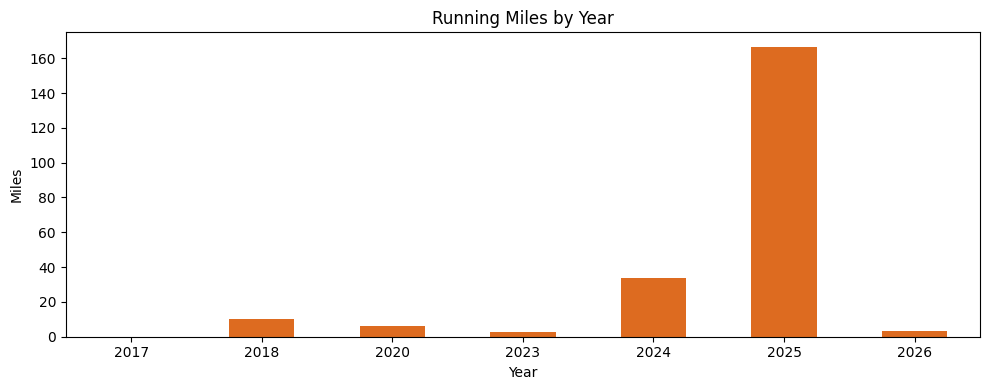

In [20]:
import matplotlib.pyplot as plt

running_miles_by_year = con.execute(
    """
    SELECT
      EXTRACT(year FROM activity_datetime)::INT AS year,
      SUM(distance_m) / 1609.344 AS total_miles
    FROM activities
    WHERE activity_datetime IS NOT NULL
      AND distance_m IS NOT NULL
      AND LOWER(activity_type) = 'run'
    GROUP BY 1
    ORDER BY 1
    """
).fetch_df()

ax = running_miles_by_year.plot(
    x="year",
    y="total_miles",
    kind="bar",
    legend=False,
    figsize=(10, 4),
    color="#dd6b20",
)

ax.set_title("Running Miles by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Miles")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()